## Predictive Machine Learning Model for Assessing Loan Default Risk in Retail Banking

## Business Context and Objective
##### Financial institutions face significant losses due to loan defaults. When borrowers fail to repay loans, banks incur direct financial costs, increased capital requirements, and reputational risks. Traditional rule-based credit assessment methods may not fully capture complex borrower risk patterns.This project develops a machine learning model to predict loan default risk using the Home Equity Loan (HMEQ) dataset. The objective is to identify high-risk borrowers before loan approval, enabling more informed lending decisions.

## Business Question

##### Can machine learning be used to accurately predict whether a borrower will default on a home equity loan, based on financial and credit history variables?

## Machine Learning Formulation

##### This problem is formulated as a supervised binary classification task, where:

##### Target variable: BAD

##### 0 = Loan repaid

##### 1 = Loan defaulted

##### The goal is to predict the probability of default using borrower financial characteristics.

In [126]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [127]:
# ==========================================
# 2. LOAD DATASET 
# ==========================================
#Load the dataset from CSV into a DataFrame so we can clean, explore, and model it.

df = pd.read_csv("hmeq.csv")


In [128]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [130]:
# ==========================================
# 3. CHECK TARGET COLUMN 
# IMPORTANT: This must show BOTH 0 and 1
# ==========================================
#Confirm the target has both classes (0 and 1). ML models cannot train if only one class exists.

print("BAD distribution:")
print(df["BAD"].value_counts(dropna=False))


BAD distribution:
BAD
0    4771
1    1189
Name: count, dtype: int64


In [131]:
# ==========================================
# 4. SEPARATE TARGET (y) AND FEATURES (X)
# IMPORTANT: Never clean/clip the target column BAD
#Note: y is what we want to predict, X are the input variables used to predict it.
#We keep them separate to avoid accidentally changing the target during cleaning.
# ==========================================
y = df["BAD"]                  # target
X = df.drop(columns=["BAD"])   # features only


In [132]:
# ==========================================
# 5. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS (FEATURES ONLY)
#We treat numeric and categorical columns differently when cleaning and encoding.
# ==========================================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
Categorical columns: ['REASON', 'JOB']


In [133]:
# ==========================================
# 6. HANDLE MISSING VALUES (FEATURES ONLY)
#Identify columns with missing values to decide the best imputation approach.
#Numeric columns → fill missing with median (robust to outliers)
#Categorical columns → fill missing with mode (most common category)
# ==========================================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Missing values BEFORE:")
print(X.isnull().sum().sort_values(ascending=False))

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values AFTER:")
print(X.isnull().sum().sort_values(ascending=False))


Missing values BEFORE:
DEBTINC    1267
DEROG       708
DELINQ      580
MORTDUE     518
YOJ         515
NINQ        510
CLAGE       308
JOB         279
REASON      252
CLNO        222
VALUE       112
LOAN          0
dtype: int64
Missing values AFTER:
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64


In [134]:
# ==========================================
# 7. ENCODE CATEGORICAL VARIABLES (FEATURES ONLY)
#Convert text categories into dummy (0/1) columns so models can use them.
# ==========================================
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape after encoding:", X.shape)


Shape after encoding: (5960, 16)


## Feature Engineering

##### To improve predictive performance and reflect real-world credit risk logic, new variables were created:

##### Loan-to-Value (LTV) = LOAN / VALUE

##### Mortgage-to-Value (MTV) = MORTDUE / VALUE

##### These ratios are commonly used in credit risk assessment.

##### Additionally, logarithmic transformations were applied to highly skewed financial variables to stabilise variance and improve model learning.

In [135]:
# ==========================================
# 7. FEATURE ENGINEERING
# ==========================================
X["LTV"] = X["LOAN"] / X["VALUE"]          # Loan-to-Value
X["MTV"] = X["MORTDUE"] / X["VALUE"]       # Mortgage-to-Value

X["LOG_LOAN"] = np.log1p(X["LOAN"])
X["LOG_VALUE"] = np.log1p(X["VALUE"])
X["LOG_DEBTINC"] = np.log1p(X["DEBTINC"])


In [136]:
# ==========================================
# 8. OUTLIER HANDLING (FEATURES ONLY - IQR CAPPING)
# We clip ONLY feature columns (X), not y
# Cap extreme values to reduce their influence on model training (applied to features only)
# ==========================================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns  # refresh after feature eng

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X[col] = X[col].clip(lower, upper)



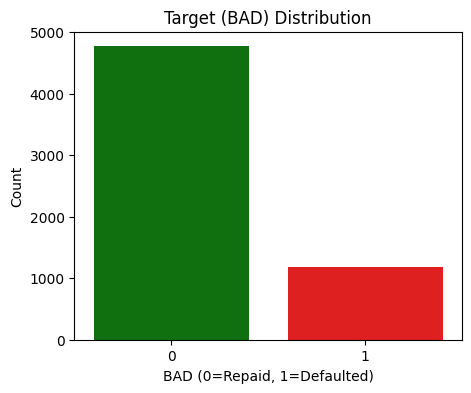

In [137]:
# ==========================================
# 9. QUICK EDA
# - Target class balance
#Visualise class imbalance (how many defaults vs non-defaults).
# ==========================================
plt.figure(figsize=(5,4))
sns.countplot(x=y, hue=y, palette={0: "green", 1: "red"}, legend=False)
plt.title("Target (BAD) Distribution")
plt.xlabel("BAD (0=Repaid, 1=Defaulted)")
plt.ylabel("Count")
plt.show()

In [138]:
# ==========================================
# 10. TRAIN / TEST SPLIT
# Split into training data (model learns) and test data (final evaluation).
# stratify=y keeps the same proportion of defaulters in both sets.
# ==========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train target distribution:\n", y_train.value_counts())
print("Test target distribution:\n", y_test.value_counts())


Train target distribution:
 BAD
0    3340
1     832
Name: count, dtype: int64
Test target distribution:
 BAD
0    1431
1     357
Name: count, dtype: int64


In [139]:
# ==========================================
# 11. MODEL 1: LOGISTIC REGRESSION (SCALED)
# Logistic Regression works better when numeric features are on similar scales, so we standardise them.
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=5000, solver="lbfgs", class_weight="balanced", random_state=42)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_prob)

print(classification_report(y_test, log_pred))


              precision    recall  f1-score   support

           0       0.89      0.68      0.77      1431
           1       0.34      0.65      0.45       357

    accuracy                           0.68      1788
   macro avg       0.61      0.67      0.61      1788
weighted avg       0.78      0.68      0.71      1788



## Logistic Regression Performance

##### The Logistic Regression model achieved moderate performance. While it captured a reasonable proportion of defaulters (recall), its precision was lower, indicating more false positive classifications.

##### This model provides a strong baseline but may not capture complex patterns effectively.

In [140]:
# ==========================================
# 12. MODEL 2: RANDOM FOREST (UNSCALED)
# Random Forest does not need scaling. It is an ensemble method (many trees voting).
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1431
           1       0.76      0.62      0.68       357

    accuracy                           0.88      1788
   macro avg       0.83      0.78      0.80      1788
weighted avg       0.88      0.88      0.88      1788



## Random Forest Performance

##### Random Forest significantly outperformed Logistic Regression in overall accuracy and ROC-AUC.

##### It demonstrated:

##### Higher precision (fewer false alarms)

##### Balanced recall

##### Stronger F1 score

##### This indicates improved ability to separate high-risk from low-risk borrowers.

In [141]:
# ==========================================
# 13. MODEL COMPARISON TABLE
# Summarise results in one table for easy comparison.
# ==========================================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.677852   0.339678  0.649860  0.446154  0.732390
1        Random Forest  0.884228   0.758621  0.616246  0.680062  0.938919


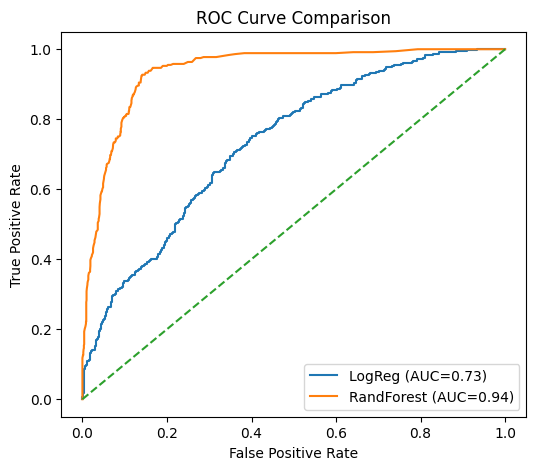

In [142]:
# ==========================================
# 14. ROC CURVE (LOG vs RF)
# Plot ROC curves for both models to compare their ability to distinguish between defaulting and non-defaulting borrowers across different classification thresholds.
# ==========================================
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(log_fpr, log_tpr, label=f"LogReg (AUC={log_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"RandForest (AUC={rf_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


#### The ROC curve compares the performance of Logistic Regression and Random Forest in distinguishing between defaulters and non-defaulters.

#### The Random Forest model (AUC = 0.94) significantly outperforms Logistic Regression (AUC = 0.73). An AUC of 0.94 indicates excellent discriminatory power, meaning the Random Forest model is highly effective at separating high-risk borrowers from low-risk borrowers.

#### In contrast, Logistic Regression shows moderate performance, with an AUC of 0.73, suggesting weaker ability to distinguish between the two classes.

#### Overall, the ROC curve demonstrates that Random Forest provides substantially better predictive performance, making it the preferred model for this credit risk classification task.

In [143]:
# ==========================================
# 15. CROSS-VALIDATION (ROC-AUC)
# Perform 5-fold cross-validation using ROC-AUC to evaluate the model’s stability and generalisation performance across multiple data splits.
# ==========================================
from sklearn.model_selection import cross_val_score

rf_cv_auc = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc").mean()
print("Random Forest CV ROC-AUC (5-fold):", rf_cv_auc)


Random Forest CV ROC-AUC (5-fold): 0.7188782377470979


In [144]:
# ==========================================
# 16. HYPERPARAMETER TUNING (GRID SEARCH)
# Use GridSearchCV to systematically test different Random Forest parameter combinations and select the model configuration 
# that maximizes ROC-AUC performance through 5-fold cross-validation.

# ==========================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

grid = GridSearchCV(
    rf_base, param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC: 0.9342676345598969


In [145]:
# ==========================================
# 17. EVALUATE TUNED RANDOM FOREST
# Evaluate the best-performing tuned Random Forest model on the test set to measure its final predictive performance 
# using multiple classification metrics.
# ==========================================
best_rf = grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)
best_rf_auc = roc_auc_score(y_test, best_rf_prob)

print("Tuned Random Forest Results")
print(classification_report(y_test, best_rf_pred))
print("ROC-AUC:", best_rf_auc)


Tuned Random Forest Results
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1431
           1       0.76      0.62      0.68       357

    accuracy                           0.88      1788
   macro avg       0.83      0.79      0.81      1788
weighted avg       0.88      0.88      0.88      1788

ROC-AUC: 0.939073183431304


In [146]:
# ==========================================
# 18. THRESHOLD TUNING (LOGISTIC REGRESSION)
# Adjust the classification threshold to increase sensitivity to default cases and analyse the trade-off between precision and recall.
# ==========================================
threshold = 0.35
log_pred_thresh = (log_prob >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, log_pred_thresh))


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.93      0.41      0.57      1431
           1       0.27      0.87      0.41       357

    accuracy                           0.50      1788
   macro avg       0.60      0.64      0.49      1788
weighted avg       0.80      0.50      0.54      1788



In [147]:
# ==========================================
# 19.CONFUSION MATRIX (TP, TN, FP, FN)
# Shows exactly what the model got right/wrong.
# Compute the confusion matrix to quantify true positives, true negatives, false positives, and false negatives for detailed performance evaluation.
# ==========================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)


True Negative (TN): 1361
False Positive (FP): 70
False Negative (FN): 137
True Positive (TP): 220


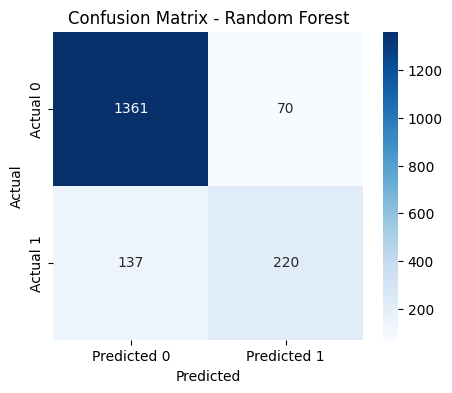

In [148]:
# ==========================================
# 20. CONFUSION MATRIX HEATMAP
# Visualise the confusion matrix as a heatmap to clearly illustrate correct and incorrect classifications 
# made by the Random Forest model.
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


##### The model correctly identified 1,361 non-defaulters and 220 defaulters. It misclassified 70 good borrowers as risky and 137 defaulters as safe.

#### Business Context

##### The model performs well overall and detects many high-risk borrowers, helping reduce potential loan losses. However, the 137 missed defaulters represent financial risk, while the 70 false alarms may increase review costs. Overall, the model is suitable as a credit risk decision-support tool.

## Conclusion

##### This project demonstrates how machine learning can be applied to predict loan default risk using structured financial data.

##### Through careful data preparation, feature engineering, model comparison, and performance tuning, the Random Forest ensemble model provided the strongest predictive performance.

##### The results highlight the value of machine learning in supporting data-driven credit risk decision-making.

In [ ]:
######## Copyright Chimeme Eme-Uche @ 2026 #######
######## Reference ChatGPT5 #######
